In [1]:
%pip install -r ../../requirements-offline.txt --quiet

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-33/.check-env/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Capstone Track C — อ่านค่าจากเอกสารการวัด 📄

**M8 Capstone (Day 3 บ่าย) · Starter notebook — รันผ่านทั้งไฟล์ได้บนเครื่อง CPU ปกติ**

โจทย์: สร้าง pipeline **สแกนรายงานการวัด → OCR → สกัดตัวเลข → ตาราง/พล็อต → วิเคราะห์**
— แทร็กเดียวที่ผสมทักษะ OCR (M2) เข้ากับทักษะตารางของคอร์ส Data Science โดยตรง
(ตาราง pandas, การตรวจความถูกต้องของข้อมูล, กราฟที่อ่านได้)

โน้ตบุ๊กนี้คือ **กรอบเริ่มต้นที่รันจบแบบ end-to-end** — ทีมต่อยอดจากจุดที่ระบุไว้
(หัวข้อ 7) ให้ครอบคลุมข้อมูลจริงของทีมและวิเคราะห์ลึกขึ้น

## Dataset / เครื่องมือที่ใช้ (citation + license)

- **ภาพสแกนรายงานการวัด** — สื่อสังเคราะห์ของคอร์ส
  (`datasets/measurement_reports/` สร้างด้วย `tools/generate_measurement_reports.py`,
  ไม่มีลิขสิทธิ์ภายนอก)
- **EasyOCR 1.7** — Apache-2.0 (โมเดลโหลดจาก cache เครื่อง — เตรียมไว้แล้วใน M2)
- ในส่วนขยาย: **Surya** table extraction (โค้ด Apache-2.0; ตรวจ license weights
  ก่อนแจกจ่ายตามที่ระบุใน M2) และ **jiwer** (Apache-2.0) สำหรับวัด CER


## 0. เตรียม — หน้าเป้าหมายของแทร็กนี้

เราใช้สองหน้าจากชุดใบรับรอบการสอบเทียบจำลอง:

- **page03** — ตารางผลการสอบเทียบ 10 จุด (ตัวเลข 5 คอลัมน์) — เป้าหมายหลัก
- **page06** — ภาคผนวด ก: บันทึกค่าการอ่านซ้ำ 3 ครั้ง — ฝึกสถิติจากตัวเลขที่ OCR ได้


In [2]:
import re  # noqa: E402
from pathlib import Path  # noqa: E402


def repo_root() -> Path:
    """หา repo root โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "requirements-offline.txt").exists():
            return p
    raise SystemExit(
        "ไม่พบ repo root — เปิด JupyterLab จาก repo root (uv run jupyter lab)"
    )


ROOT = repo_root()
REPORTS = ROOT / "datasets" / "measurement_reports"
PAGE3 = REPORTS / "page03.png"   # ตารางผลการสอบเทียบ 10 จุด
PAGE6 = REPORTS / "page06.png"   # ภาคผนวด ก: ค่าอ่านซ้ำ
assert PAGE3.exists() and PAGE6.exists(), (
    "ไม่พบ datasets/measurement_reports — ดู datasets/README.md"
)
print("repo root:", ROOT)


repo root: /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-33


มองหน้าเป้าหมายก่อน — ตารางตัวเลขที่เราจะ "อ่านให้กลับมาเป็นข้อมูลตาราง" อีกครั้ง:

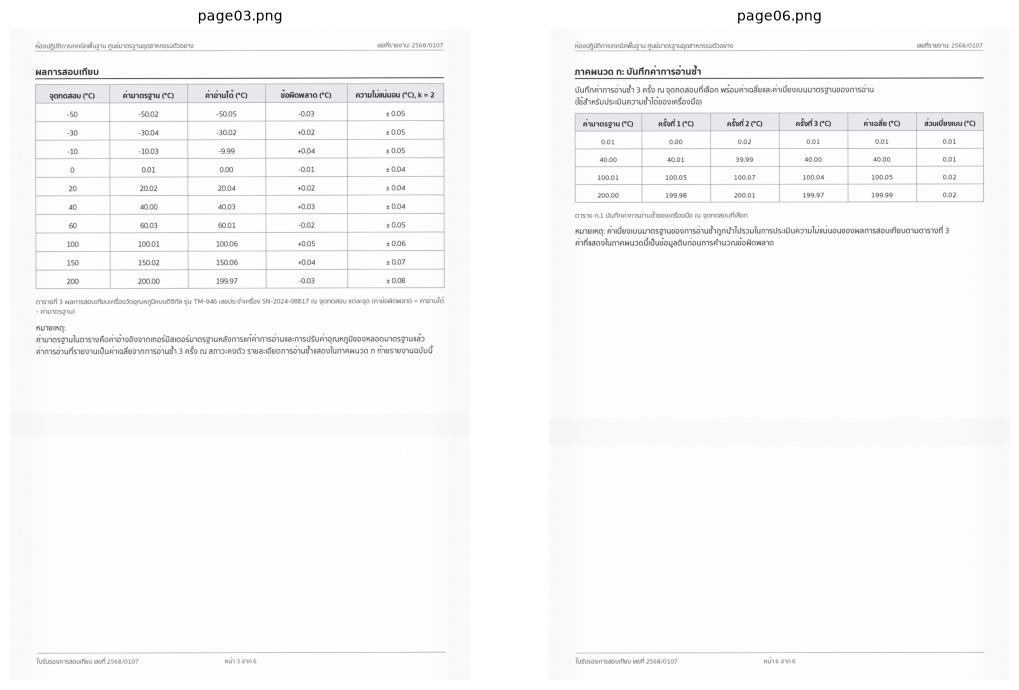

In [3]:
import matplotlib.pyplot as plt  # noqa: E402
from PIL import Image  # noqa: E402

plt.rcParams["font.family"] = ["DejaVu Sans", "Noto Sans Thai", "Tahoma"]
fig, axes = plt.subplots(1, 2, figsize=(11, 7))
for ax, path in zip(axes, [PAGE3, PAGE6]):
    ax.imshow(Image.open(path))
    ax.set_title(path.name, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 1. OCR เต็มหน้าด้วย EasyOCR — คราวนี้เราต้องการ "ตำแหน่ง" ด้วย

M2 ใช้ `detail=0` (ได้ข้อความอย่างเดียว) — แต่การสกัดตารางต้องรู้ **ว่าตัวเลขไหน
อยู่คอลัมน์ไหน** จึงใช้ `detail=1` ซึ่งคืน bounding box 4 มุมต่อ box
เราย่อเป็นจุดกึ่งกลาง (x, y) เพื่อจัดกลุ่มต่อไป


In [4]:
import easyocr  # noqa: E402
import numpy as np  # noqa: E402

reader = easyocr.Reader(["th", "en"], gpu=False, verbose=False)


def read_page(path) -> list[tuple[float, float, str]]:
    """OCR ทั้งหน้า → [(x_center, y_center, text), ...]."""
    img = Image.open(path).convert("RGB")
    out = []
    for bb, txt, _conf in reader.readtext(
        np.array(img), detail=1, paragraph=False
    ):
        xs = [p[0] for p in bb]
        ys = [p[1] for p in bb]
        out.append((float(np.mean(xs)), float(np.mean(ys)), txt))
    return out


boxes3 = read_page(PAGE3)
print("จำนวน box ทั้งหน้า:", len(boxes3))
for x, y, txt in boxes3[:14]:
    print(f"  y={y:6.0f}  x={x:6.0f}  {txt!r}")


/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-33/.check-env/lib/python3.14/site-packages/torch/ao/nn/quantized/dynamic/modules/rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/quantized/Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-33/.check-env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


จำนวน box ทั้งหน้า: 67
  y=    44  x=   280  'หองปฏิบัติการเทคนิคพื้นฐาน ศูนย์มาตรฐานอุตสาหกรรมตัวอย่าง'
  y=    43  x=  1078  'เลขที่รายงาน: 2568/0107'
  y=   116  x=   154  'ผลการสอบเทียบ'
  y=   182  x=   168  ' จุดทดสอบ (`c)'
  y=   179  x=   372  'ค่ามาตรฐาน (`c)'
  y=   178  x=   584  'ค่าอ่านได้ ( c)'
  y=   176  x=   797  'ข้อผิดพลาด (`c)'
  y=   177  x=  1037  'ความไมแน่นอน (`), k= 2'
  y=   230  x=   172  '50'
  y=   230  x=   375  '-50.02'
  y=   229  x=   587  '50.05'
  y=   229  x=   801  '0.03'
  y=   228  x=  1039  '+ o.05'
  y=   280  x=   171  '-30'


## 2. จาก box → ตาราง

กลยุทธ์ 3 ชั้น:

1. **กรอง token ตัวเลข** — ล้างสัญลักษณ์รบกวนทิ้ง (OCR มักอ่าน `0` เป็น `o`, `1` เป็น `l`)
2. **จับกลุ่มเป็นแถวด้วย y** — token ที่อยู่ใกล้กันในแนวตั้ง = แถวเดียวกัน
3. **จัดคอลัมน์ด้วย x** — ใช้ตำแหน่งหัวตารางเป็น anchor (ทำให้แถวที่ OCR หล่น
   ช่องหนึ่งยังลงคอลัมน์ถูก — จุดที่ "เรียงตาม x ในแถว" พลาดทันที)


In [5]:
HEADER_KEYS = [
    "จุดทดสอบ", "ค่ามาตรฐาน", "ค่าอ่านได้", "ข้อผิดพลาด", "ความไม",
]


def numberish(txt: str) -> bool:
    """จริงเมื่อ token เหลือแต่ตัวเลข/จุด/เครื่องหมายหลังล้างขยะ."""
    s = (txt.replace("o", "0").replace("O", "0")
         .replace("l", "1").replace("I", "1"))
    s = re.sub(r"[^0-9.+\-]", "", s)
    return bool(re.search(r"\d", s)) and len(s) <= 8


def to_float(txt: str) -> float | None:
    """token OCR → float (แก้ 'o'→'0' ก่อน); อ่านไม่ออก → None."""
    s = (txt.replace("o", "0").replace("O", "0")
         .replace("l", "1").replace("I", "1"))
    s = re.sub(r"[^0-9.+\-]", "", s)
    m = re.search(r"[-+]?\d*\.\d+|[-+]?\d+", s)
    return float(m.group()) if m else None


def cluster_rows(items, y_tol=25):
    """เรียงตาม y แล้วจับกลุ่ม — ช่องว่าง > y_tol = เริ่มแถวใหม่."""
    items = sorted(items, key=lambda v: v[1])
    rows, cur, last = [], [], None
    for x, y, txt in items:
        if last is not None and y - last > y_tol:
            rows.append(cur)
            cur = []
        cur.append((x, txt))
        last = y
    if cur:
        rows.append(cur)
    return rows


def ocr_table(boxes, n_cols, anchors=None, y0=0.0, y1=1e9):
    """box → ตาราง n_cols คอลัมน์; มี anchor = จัดคอลัมน์ด้วยหัวตาราง."""
    num = [(x, y, t) for x, y, t in boxes
           if y0 < y < y1 and numberish(t)]
    table = []
    for row in cluster_rows(num):
        if anchors is None:      # ทุกช่องครบ — เรียงตาม x ในแถว
            cells = sorted(row, key=lambda v: v[0])[:n_cols]
            vals = [to_float(t) for _, t in cells]
        else:                    # ช่องหายก็ยังลงคอลัมน์ถูก
            vals = [None] * n_cols
            for x, t in row:
                col = min(range(n_cols),
                          key=lambda i: abs(x - anchors[i]))
                vals[col] = to_float(t)
        table.append(vals + [None] * (n_cols - len(vals)))
    return table


หา anchor จากหัวตาราง กำหนดแถบ y ของตาราง (คัดส่วนหัวกระดาษ/คำบรรยายออก)
แล้วดึง 10 แถวออกมาเป็น DataFrame:

In [6]:
import pandas as pd  # noqa: E402

hdr = {}
for x, y, txt in boxes3:
    for key in HEADER_KEYS:
        if key in txt and key not in hdr:
            hdr[key] = (x, y)

anchors = [hdr[k][0] for k in HEADER_KEYS]
y_top = max(y for _, y in hdr.values())
y_bot = min(y for _, y, t in boxes3 if "ตาราง" in t and y > y_top)
print("anchor x:", [round(a) for a in anchors],
      "| แถบตาราง y:", round(y_top), "-", round(y_bot))

COLS3 = ["จุดทดสอบ", "ค่ามาตรฐาน", "ค่าอ่านได้", "ข้อผิดพลาด",
         "ความไม่แน่นอน"]
df3 = pd.DataFrame(
    ocr_table(boxes3, 5, anchors=anchors, y0=y_top, y1=y_bot),
    columns=COLS3,
).apply(pd.to_numeric, errors="coerce")
print(df3.to_string())


anchor x: [168, 372, 584, 797, 1037] | แถบตาราง y: 182 - 734
   จุดทดสอบ  ค่ามาตรฐาน  ค่าอ่านได้  ข้อผิดพลาด  ความไม่แน่นอน
0      50.0      -50.02       50.05        0.03           0.05
1     -30.0       30.04      -30.02        0.02           0.05
2      10.0       10.03        9.99        0.04           0.05
3       NaN        0.01        0.00       -0.01           0.04
4      20.0       20.02       20.04        0.02           0.04
5      40.0       40.00       40.03        0.03           0.04
6      60.0       60.03       60.01       -0.02           0.05
7     100.0      100.01      100.06        0.05           0.06
8     150.0      150.02      150.06        0.04           0.07
9     200.0      200.00      199.97        0.00           0.08


## 3. ตรวจตัวเลขด้วย "ความสอดคล้องภายใน" — ทักษะเมโทรโลยี + DS รวมกัน

ความผิดพลาด OCR ที่พบบ่อยที่สุดกับเอกสารตัวเลข: **หล่นเครื่องหมายลบ** และ `0`↔`o`
เราตรวจได้โดยไม่ต้องมีเฉลย เพราะรายงานการวัดมีกฎเหล็กติดตัว:
**ข้อผิดพลาด = ค่าอ่านได้ − ค่ามาตรฐาน** — แถวไหนที่สองค่านี้ไม่ตรงกัน = แถวนั้น
ต้องตรวจตา/อ่านซ้ำ

⚠️ ข้อจำกัดที่ต้องพูดในการนำเสนอ: ถ้าทั้งแถวหล่นเครื่องหมายลบพร้อมกัน
(ค่ามาตรฐานและค่าอ่านได้พร้อมกัน) ค่าที่คำนวณยัง "สอดคล้อง" อยู่ —
การตรวจภายในจับไม่ได้ ต้องมีตารางอ้างอิงหรือตาคน


In [7]:
df3["err_calc"] = df3["ค่าอ่านได้"] - df3["ค่ามาตรฐาน"]
df3["ต่างจากที่รายงาน"] = (df3["err_calc"] - df3["ข้อผิดพลาด"]).abs()
print(df3.round(2).to_string())
bad = df3["ต่างจากที่รายงาน"] > 0.02
print("\nแถวที่ต้องตรวจตา (คลาดเคลื่อน > 0.02 °C):")
print(df3[bad].round(2).to_string())


   จุดทดสอบ  ค่ามาตรฐาน  ค่าอ่านได้  ข้อผิดพลาด  ความไม่แน่นอน  err_calc  ต่างจากที่รายงาน
0      50.0      -50.02       50.05        0.03           0.05    100.07            100.04
1     -30.0       30.04      -30.02        0.02           0.05    -60.06             60.08
2      10.0       10.03        9.99        0.04           0.05     -0.04              0.08
3       NaN        0.01        0.00       -0.01           0.04     -0.01              0.00
4      20.0       20.02       20.04        0.02           0.04      0.02              0.00
5      40.0       40.00       40.03        0.03           0.04      0.03              0.00
6      60.0       60.03       60.01       -0.02           0.05     -0.02              0.00
7     100.0      100.01      100.06        0.05           0.06      0.05              0.00
8     150.0      150.02      150.06        0.04           0.07      0.04              0.00
9     200.0      200.00      199.97        0.00           0.08     -0.03              0.03

## 4. เทียบกับตารางอ้างอิง — วัดความแม่นยำระดับเซลล์

ภาพชุดนี้ถูกสร้างด้วยโปรแกรม เราจึงมีตารางจริงมาเทียบได้ (ในงานจริงตำแหน่งนี้
คือการตรวจตาโดยคน, การสแกนซ้ำด้วยเครื่องอื่น หรือการเทียบกับระบบอื่น)


In [8]:
REF = pd.DataFrame({
    "จุดทดสอบ": [-50, -30, -10, 0, 20, 40, 60, 100, 150, 200],
    "ค่ามาตรฐาน": [-50.02, -30.04, -10.03, 0.01, 20.02, 40.00,
                   60.03, 100.01, 150.02, 200.00],
    "ค่าอ่านได้": [-50.05, -30.02, -9.99, 0.00, 20.04, 40.03,
                   60.01, 100.06, 150.06, 199.97],
    "ข้อผิดพลาด": [-0.03, 0.02, 0.04, -0.01, 0.02, 0.03, -0.02,
                   0.05, 0.04, -0.03],
    "ความไม่แน่นอน": [0.05, 0.05, 0.05, 0.04, 0.04, 0.04, 0.05,
                      0.06, 0.07, 0.08],
})
hits = 0
for col in COLS3:
    got = df3[col].to_numpy()
    want = REF[col].to_numpy(dtype=float)
    ok = (~np.isnan(got)) & (np.abs(got - want) < 0.005)
    hits += int(ok.sum())
    print(f"  {col}: อ่านถูก {int(ok.sum())}/10 ช่อง")
n_cells = len(REF) * 5
print(f"\nความแม่นยำระดับเซลล์ = {hits}/{n_cells} = {hits / n_cells:.0%}")


  จุดทดสอบ: อ่านถูก 7/10 ช่อง
  ค่ามาตรฐาน: อ่านถูก 8/10 ช่อง
  ค่าอ่านได้: อ่านถูก 8/10 ช่อง
  ข้อผิดพลาด: อ่านถูก 8/10 ช่อง
  ความไม่แน่นอน: อ่านถูก 10/10 ช่อง

ความแม่นยำระดับเซลล์ = 41/50 = 82%


## 5. พล็อตผลที่ OCR ได้ — เทียบกับกราฟในรายงานเอง

หน้า 4 ของรายงานมีกราฟข้อผิดพลาดพร้อมแถบความไม่แน่นอน — เราสร้างกราฟเดียวกัน
**จากตัวเลขที่อ่านได้ด้วย OCR** แล้ววางค่าอ้างอิงซ้อนเทียบ (จุดที่หล่นเครื่องหมายลบ
จะเห็นชัดในกราฟทันที)


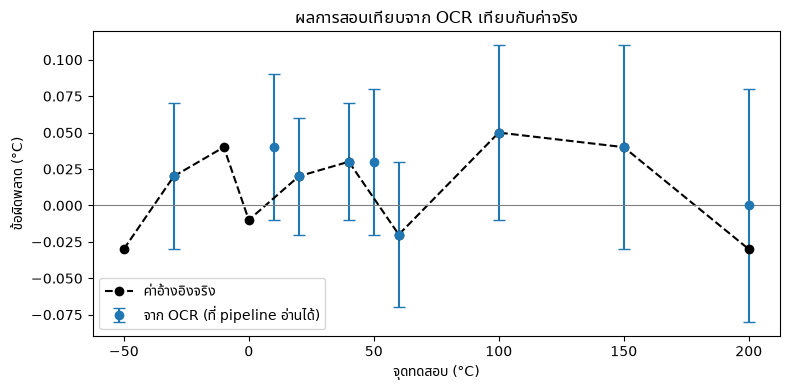

In [9]:
plot = df3.dropna(subset=["จุดทดสอบ"]).sort_values("จุดทดสอบ")
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(
    plot["จุดทดสอบ"], plot["ข้อผิดพลาด"],
    yerr=plot["ความไม่แน่นอน"], fmt="o", capsize=4,
    label="จาก OCR (ที่ pipeline อ่านได้)",
)
ax.plot(REF["จุดทดสอบ"], REF["ข้อผิดพลาด"], "k--o",
        label="ค่าอ้างอิงจริง")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("จุดทดสอบ (°C)")
ax.set_ylabel("ข้อผิดพลาด (°C)")
ax.set_title("ผลการสอบเทียบจาก OCR เทียบกับค่าจริง")
ax.legend()
plt.tight_layout()
plt.show()


## 6. ภาคผนวด ก — ค่าอ่านซ้ำ → สถิติ (ทักษะ DS ตารางมาเต็ม ๆ)

หน้า 06 เป็นตารางตัวเลขล้วน 6 คอลัมน์ทุกช่องครบ — ใช้โหมด "เรียงตาม x ในแถว"
ได้เลย แล้วคำนวณค่าเฉลี่ย/ส่วนเบี่ยงเบนมาตรฐานจาก 3 ครั้งที่อ่านได้
เทียบกับคอลัมน์ที่รายงานพิมพ์ไว้ (อีกชั้นของการตรวจความสอดคล้อง)


In [10]:
boxes6 = read_page(PAGE6)
y_top6 = min(y for _, y, t in boxes6 if "ครั้งที่" in t)
y_bot6 = min(y for _, y, t in boxes6 if "ก.1" in t and y > y_top6)
COLS6 = ["ค่ามาตรฐาน", "ครั้งที่ 1", "ครั้งที่ 2", "ครั้งที่ 3",
         "ค่าเฉลี่ย", "ส่วนเบี่ยงเบน"]
df6 = pd.DataFrame(
    ocr_table(boxes6, 6, y0=y_top6 + 20, y1=y_bot6),
    columns=COLS6,
).apply(pd.to_numeric, errors="coerce")
print(df6.round(2).to_string())

reads = df6[["ครั้งที่ 1", "ครั้งที่ 2", "ครั้งที่ 3"]]
df6["เฉลี่ย (คำนวณ)"] = reads.mean(axis=1)
df6["ส่วนเบี่ยงเบน (คำนวณ)"] = reads.std(axis=1, ddof=1)
d_mean = (df6["เฉลี่ย (คำนวณ)"] - df6["ค่าเฉลี่ย"]).abs()
d_sd = (df6["ส่วนเบี่ยงเบน (คำนวณ)"] - df6["ส่วนเบี่ยงเบน"]).abs()
print("\n|เฉลี่ย คำนวณ − ที่รายงาน| สูงสุด =", round(float(d_mean.max()), 3))
print("|ส่วนเบี่ยงเบน คำนวณ − ที่รายงาน| สูงสุด =",
      round(float(d_sd.max()), 3))


/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-33/.check-env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


   ค่ามาตรฐาน  ครั้งที่ 1  ครั้งที่ 2  ครั้งที่ 3  ค่าเฉลี่ย  ส่วนเบี่ยงเบน
0        0.01        0.00        0.02        0.01       0.01           0.01
1       40.00       40.01       39.99       40.00      40.00           0.01
2      100.01      100.05      100.07      100.04     100.05           0.02
3      200.00      199.98      200.01      199.97     199.99           0.02

|เฉลี่ย คำนวณ − ที่รายงาน| สูงสุด = 0.003
|ส่วนเบี่ยงเบน คำนวณ − ที่รายงาน| สูงสุด = 0.005


## 7. ทางทีมต่อยอด — รวมถึง "ข้อมูลจริงของทีม" (bring-your-own)

**ใช้สแกนของทีมเอง:** เก็บไฟล์ไว้ที่ `data/capstone_c/` (gitignored) —
ถ่าย/สแกนเอกสารการวัดจริงของหน่วยงาน **เฉพาะข้อมูลที่เปิดเผยได้** แล้วชี้
`PAGE3`/`PAGE6` ไปที่ไฟล์ของทีม ข้อควรทำให้ OCR อ่านออก:

- ความละเอียด ≥ 300 dpi หรือกล้อง 12 MP ขึ้นไป, วางเอกสารระนาบ แสงสม่ำเสมอ
- ตารางซับซ้อน (เส้นรวม/หลายหน้า) — ใช้ **Surya table extraction** จาก M2
  ช่วยหาเซลล์ก่อน แล้ว OCR เฉพาะ crop ของแต่ละเซลล์ (โค้ดตัวอย่างใน M2 book)
- วัดคุณภาพ OCR เชิงข้อความด้วย **CER (jiwer)** แบบ M2 ได้ ถ้าทีมพิมพ์เฉลย
  สั้น ๆ เอง (เช่นพิมพ์เฉพาะแถวตัวเลข 10 แถว — งานไม่กี่นาที คุ้มมาก)

**ขยายการวิเคราะห์ (ทักษะ DS ตาราง):**

- ฟิต **เส้น calibration** (regression จากคอร์ส DS) จากค่ามาตรฐาน → ค่าอ่านได้
  แล้วรายงาน residual ต่อจุด
- รวมหลายไฟล์รายงานเป็นตารางเดียว (เช่นรายงาน 6 เดือนย้อนหลัง) แล้วดูแนวโน้ม
  ข้อผิดพลาด — เชื่อมโจทย์ "calibration interval" ของสายงาน
- ซ่อมเครื่องหมายลบอัตโนมัติด้วยกฎโดเมน (เช่น จุดทดสอบเรียงจากติดลบ → บวก)
  แล้ววัดว่าความแม่นยำเซลล์เพิ่มขึ้นกี่เปอร์เซ็นต์ — นำเสนอตัวเลขนี้ได้เลย

## สิ่งที่ผลงานต้องมี (ตรวจด้วย rubric)

1. Pipeline รันจบตั้งแต่ภาพสแกน → ตาราง (Restart & Run All ผ่าน)
2. มีการ**ตรวจคุณภาพของตัวเลข**อย่างน้อยหนึ่งชั้น (ความสอดคล้องภายใน
   และ/หรือเทียบตารางอ้างอิง) พร้อมรายงาน % ความแม่นยำ
3. พล็อตอย่างน้อยหนึ่งภาพที่อ่านค่าจากข้อมูลที่สกัดได้
4. ย่อหน้าข้อจำกัด: OCR พลาดแบบไหนบ่อย และแผนจัดการ (สแกนใหม่/กฎโดเมน/ตรวจตา)
5. สไลด์ 10 นาที — โครงตาม `rubric.md`
